# Работу выполнил студент ДПИ25-1 Карчевский Андрей

# Лабораторная работа 4: Работа с таблицами (Excel + pandas)

## Разминка (файл `себестоимостьА_в1.xlsx`)

**Цель:** для области *«Пшеничный хлеб»* на листе `Рецептура` посчитать себестоимость каждого вида продукции как сумму `расход_ресурса × цена_ресурса` по всем ресурсам.

Далее результат:
- сохраняется в добавленном столбце;
- форматируется под стиль таблицы;
- дополнительно показывается вариант расчёта через формулы Excel (для «протягивания»).

In [1]:

import openpyxl
from openpyxl.styles import Font, Alignment
from openpyxl.utils import get_column_letter

src_path = "себестоимостьА_в1.xlsx"
out_path = "себестоимостьА_в1_warmup.xlsx"

wb = openpyxl.load_workbook(src_path)
ws = wb["Рецептура"]

# В исходном файле цены ресурсов находятся в строке 14, а расход ресурсов — в строках с продуктами (7–10)
price_row = 14
resource_cols = list(range(7, 16))  # G..O в исходной таблице

prices = {c: ws.cell(price_row, c).value for c in resource_cols}

# Строки с продуктами в области "Пшеничный хлеб" (где заполнено наименование продукции в колонке C)
product_rows = [r for r in range(7, 19) if ws.cell(r, 3).value]

# 1) Численный расчёт себестоимости в Python
costs = []
for r in product_rows:
    total = 0.0
    for c in resource_cols:
        q = ws.cell(r, c).value
        p = prices.get(c)
        if q is None or p is None:
            continue
        total += float(q) * float(p)
    costs.append(total)

# 2) Добавляем столбец "Себестоимость, руб." (вставляем перед блоком ресурсов)
ws.insert_cols(7)  # новый столбец G
ws.cell(4, 7).value = "Себестоимость, руб."
ws.cell(4, 7).font = Font(bold=True)
ws.cell(4, 7).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

for r, cost in zip(product_rows, costs):
    ws.cell(r, 7).value = round(cost, 3)
    ws.cell(r, 7).number_format = "0.000"

# 3) Вариант с формулой Excel для "протягивания"
ws.insert_cols(8)  # новый столбец H
ws.cell(4, 8).value = "Себестоимость (формула)"
ws.cell(4, 8).font = Font(bold=True)
ws.cell(4, 8).alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

# После двух вставок блок ресурсов сдвинулся: теперь это I..Q (9..17)
resource_cols_new = list(range(9, 18))
for r in product_rows:
    qty_range = f"{get_column_letter(resource_cols_new[0])}{r}:{get_column_letter(resource_cols_new[-1])}{r}"
    price_range = f"{get_column_letter(resource_cols_new[0])}{price_row}:{get_column_letter(resource_cols_new[-1])}{price_row}"
    ws.cell(r, 8).value = f"=SUMPRODUCT({qty_range},{price_range})"
    ws.cell(r, 8).number_format = "0.000"

wb.save(out_path)
out_path


'себестоимостьА_в1_warmup.xlsx'

Проверим получившиеся значения себестоимости для 4 видов пшеничного хлеба.

In [2]:

import pandas as pd
import openpyxl

wb = openpyxl.load_workbook("себестоимостьА_в1_warmup.xlsx", data_only=False)
ws = wb["Рецептура"]

# После вставки столбцов: себестоимость числом в G, формула в H
rows = [7, 8, 9, 10]
data = []
for r in rows:
    name = ws.cell(r, 3).value
    cost_num = ws.cell(r, 7).value
    cost_formula = ws.cell(r, 8).value
    data.append((r, name, cost_num, cost_formula))

pd.DataFrame(data, columns=["row", "product", "cost_value", "cost_formula"])


,row,product,cost_value,cost_formula
0,7,Хлеб Венгерский,21.480,"=SUMPRODUCT(I7:Q7,I14:Q14)"
1,8,"Хлеб ""Барбари""",16.525,"=SUMPRODUCT(I8:Q8,I14:Q14)"
2,9,Багет парижский,17.423,"=SUMPRODUCT(I9:Q9,I14:Q14)"
3,10,Чиабатта,18.085,"=SUMPRODUCT(I10:Q10,I14:Q14)"


## Лабораторная работа 7.1 (pandas → Excel)

1) Загружаем таблицы `reviews_sample.csv` и `recipes_sample.csv` в `pd.DataFrame`.

2) Случайно выбираем 5% строк из каждой таблицы и сохраняем в один Excel-файл `recipes.xlsx` на 2 листа: `Рецепты` и `Отзывы`.

3–7) Дальше работаем с файлом как с книгой Excel: добавляем столбцы, формулы и форматирование.

In [3]:

import pandas as pd

reviews = pd.read_csv("reviews_sample.csv", index_col=0)
recipes = pd.read_csv("recipes_sample.csv", index_col=0)

# В recipes_sample.csv имя рецепта находится в индексе (name), поэтому преобразуем индекс в колонку
recipes = recipes.reset_index()

# Оставляем только требуемые столбцы
recipes = recipes[["id", "name", "minutes", "submitted", "description", "n_ingredients"]]

# 5% случайных строк
recipes_s = recipes.sample(frac=0.05, random_state=42)
reviews_s = reviews.reset_index().sample(frac=0.05, random_state=42)

out_xlsx = "recipes.xlsx"
with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
    recipes_s.to_excel(writer, sheet_name="Рецепты", index=False)
    reviews_s.to_excel(writer, sheet_name="Отзывы", index=False)

(out_xlsx, recipes_s.shape, reviews_s.shape)


('recipes.xlsx', (1500, 6), (6335, 6))

In [4]:

import openpyxl
from openpyxl.styles import Font, Alignment, PatternFill
from openpyxl.utils import get_column_letter

def autofit_columns(ws, min_width=8, max_width=60):
    for col in range(1, ws.max_column + 1):
        max_len = 0
        for r in range(1, ws.max_row + 1):
            v = ws.cell(r, col).value
            if v is None:
                continue
            max_len = max(max_len, len(str(v)))
        ws.column_dimensions[get_column_letter(col)].width = min(max(min_width, max_len + 2), max_width)

wb = openpyxl.load_workbook("recipes.xlsx")
ws_rec = wb["Рецепты"]
ws_rev = wb["Отзывы"]

# 3) seconds_assign: присваиванием массива значений (в терминах Python — массовая запись по строкам)
ws_rec.insert_cols(7)
ws_rec.cell(1, 7).value = "seconds_assign"
for r in range(2, ws_rec.max_row + 1):
    m = ws_rec.cell(r, 3).value  # minutes
    ws_rec.cell(r, 7).value = None if m is None else float(m) * 60

# 4) seconds_formula: формулой Excel
ws_rec.insert_cols(8)
ws_rec.cell(1, 8).value = "seconds_formula"
for r in range(2, ws_rec.max_row + 1):
    ws_rec.cell(r, 8).value = f"=C{r}*60"

# 5) Заголовки добавленных столбцов — полужирные и по центру
for col in [7, 8]:
    c = ws_rec.cell(1, col)
    c.font = Font(bold=True)
    c.alignment = Alignment(horizontal="center", vertical="center")

# 6) Раскраска minutes по правилу
minutes_col = 3
fill_green = PatternFill("solid", fgColor="00FF00")
fill_yellow = PatternFill("solid", fgColor="FFFF00")
fill_red = PatternFill("solid", fgColor="FF0000")

for r in range(2, ws_rec.max_row + 1):
    m = ws_rec.cell(r, minutes_col).value
    if m is None:
        continue
    m = float(m)
    if m < 5:
        ws_rec.cell(r, minutes_col).fill = fill_green
    elif 5 <= m <= 10:
        ws_rec.cell(r, minutes_col).fill = fill_yellow
    else:
        ws_rec.cell(r, minutes_col).fill = fill_red

# 7) n_reviews: формула Excel COUNTIF по листу "Отзывы" (recipe_id находится в колонке C)
ws_rec.insert_cols(9)
ws_rec.cell(1, 9).value = "n_reviews"
ws_rec.cell(1, 9).font = Font(bold=True)
ws_rec.cell(1, 9).alignment = Alignment(horizontal="center", vertical="center")

for r in range(2, ws_rec.max_row + 1):
    ws_rec.cell(r, 9).value = f'=COUNTIF(Отзывы!$C:$C,$A{r})'

autofit_columns(ws_rec)
autofit_columns(ws_rev)

wb.save("recipes.xlsx")
"recipes.xlsx"


'recipes.xlsx'

## Лабораторная работа 7.2

### 8) Валидация листа `Отзывы`

Пишем функцию `validate()`, которая проверяет:
- `rating` ∈ [0; 5]
- `recipe_id` присутствует на листе `Рецепты`

Некорректные строки выделяем красной заливкой.

In [5]:

import openpyxl
from openpyxl.styles import PatternFill

def validate(path="recipes.xlsx"):
    wb = openpyxl.load_workbook(path)
    ws_rec = wb["Рецепты"]
    ws_rev = wb["Отзывы"]

    recipe_ids = set(ws_rec.cell(r, 1).value for r in range(2, ws_rec.max_row + 1))

    invalid_fill = PatternFill("solid", fgColor="FF6666")
    rating_col = 5   # rating
    recipe_id_col = 3  # recipe_id

    invalid_count = 0
    for r in range(2, ws_rev.max_row + 1):
        rid = ws_rev.cell(r, recipe_id_col).value
        rating = ws_rev.cell(r, rating_col).value

        ok = True
        try:
            rating = float(rating)
            if not (0 <= rating <= 5):
                ok = False
        except:
            ok = False

        if rid not in recipe_ids:
            ok = False

        if not ok:
            invalid_count += 1
            for c in range(1, ws_rev.max_column + 1):
                ws_rev.cell(r, c).fill = invalid_fill

    wb.save(path)
    return invalid_count

validate("recipes.xlsx")


6028

### 9–12) Модель предметной области (`recipes_model.csv` → `recipes_model.xlsx`)

9) Читаем модель из `recipes_model.csv` (разделитель `\t`) и записываем на лист `Модель` начиная с `A2`.

10) В столбец **J** добавляем формулу, формирующую SQL-описание атрибута.

11) Стилизуем заголовки (заливка `00ccff`, жирный шрифт), делаем автоподбор ширины и добавляем автофильтр.

12) Строим статистику: считаем число атрибутов на сущность и добавляем столбчатую диаграмму на лист `Статистика` (с позиции `E2`).

Ниже дополнительно формируем «скриншоты» листов в виде картинок (как артефакты текущего состояния таблиц).

In [6]:

import csv
import pandas as pd
import openpyxl
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, PatternFill
from openpyxl.utils import get_column_letter
from openpyxl.chart import BarChart, Reference

def autofit_columns(ws, min_width=8, max_width=60):
    for col in range(1, ws.max_column + 1):
        max_len = 0
        for r in range(1, ws.max_row + 1):
            v = ws.cell(r, col).value
            if v is None:
                continue
            max_len = max(max_len, len(str(v)))
        ws.column_dimensions[get_column_letter(col)].width = min(max(min_width, max_len + 2), max_width)

# 9) читаем модель (TSV)
rows = []
with open("recipes_model.csv", newline="", encoding="utf-8") as f:
    reader = csv.reader(f, delimiter="\t")
    for row in reader:
        rows.append(row)

headers = ["Таблица","Атрибут","Тип","Обязательно к заполнению","Сущность","Описание","Ключ","Связь: таблица","Связь: столбец","SQL"]

wb = Workbook()
ws = wb.active
ws.title = "Модель"

# Заголовки
for c, h in enumerate(headers, start=1):
    cell = ws.cell(1, c, h)
    cell.fill = PatternFill("solid", fgColor="00ccff")
    cell.font = Font(bold=True)
    cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)

# Данные начиная с A2
for i, row in enumerate(rows, start=2):
    for c, v in enumerate(row, start=1):
        ws.cell(i, c).value = v

max_row = 1 + len(rows)

# 10) формула в столбце J (SQL)
for r in range(2, max_row + 1):
    ws.cell(r, 10).value = (
        f'=B{r}&" "&UPPER(C{r})&'
        f'IF(G{r}="PK"," PRIMARY KEY",IF(G{r}="FK"," REFERENCES "&H{r}&"("&I{r}&")",""))&'
        f'IF(AND(D{r}="Y",G{r}<>"PK")," NOT NULL","")'
    )

# 11) оформление и автофильтр
ws.auto_filter.ref = f"A1:J{max_row}"
autofit_columns(ws)

# 12) статистика
df = pd.DataFrame(rows, columns=["table","column","type","required","entity","desc","key","ref_table","ref_col"])
stats = df.groupby("table")["column"].count().reset_index(name="n_attributes")

ws_stat = wb.create_sheet("Статистика")
ws_stat["A1"] = "Таблица"
ws_stat["B1"] = "Кол-во атрибутов"
ws_stat["A1"].font = Font(bold=True)
ws_stat["B1"].font = Font(bold=True)

for i, (t, n) in enumerate(zip(stats["table"], stats["n_attributes"]), start=2):
    ws_stat.cell(i, 1).value = t
    ws_stat.cell(i, 2).value = int(n)

autofit_columns(ws_stat)

chart = BarChart()
chart.title = "Количество атрибутов по сущностям"
chart.y_axis.title = "Кол-во атрибутов"
chart.x_axis.title = "Сущность"

data_ref = Reference(ws_stat, min_col=2, min_row=1, max_row=1+len(stats))
cats_ref = Reference(ws_stat, min_col=1, min_row=2, max_row=1+len(stats))
chart.add_data(data_ref, titles_from_data=True)
chart.set_categories(cats_ref)

ws_stat.add_chart(chart, "E2")

wb.save("recipes_model.xlsx")
("recipes_model.xlsx", stats)


('recipes_model.xlsx',
     table  n_attributes
 0  recipe             8
 1  review             6
 2    user             3)

Matplotlib is building the font cache; this may take a moment.


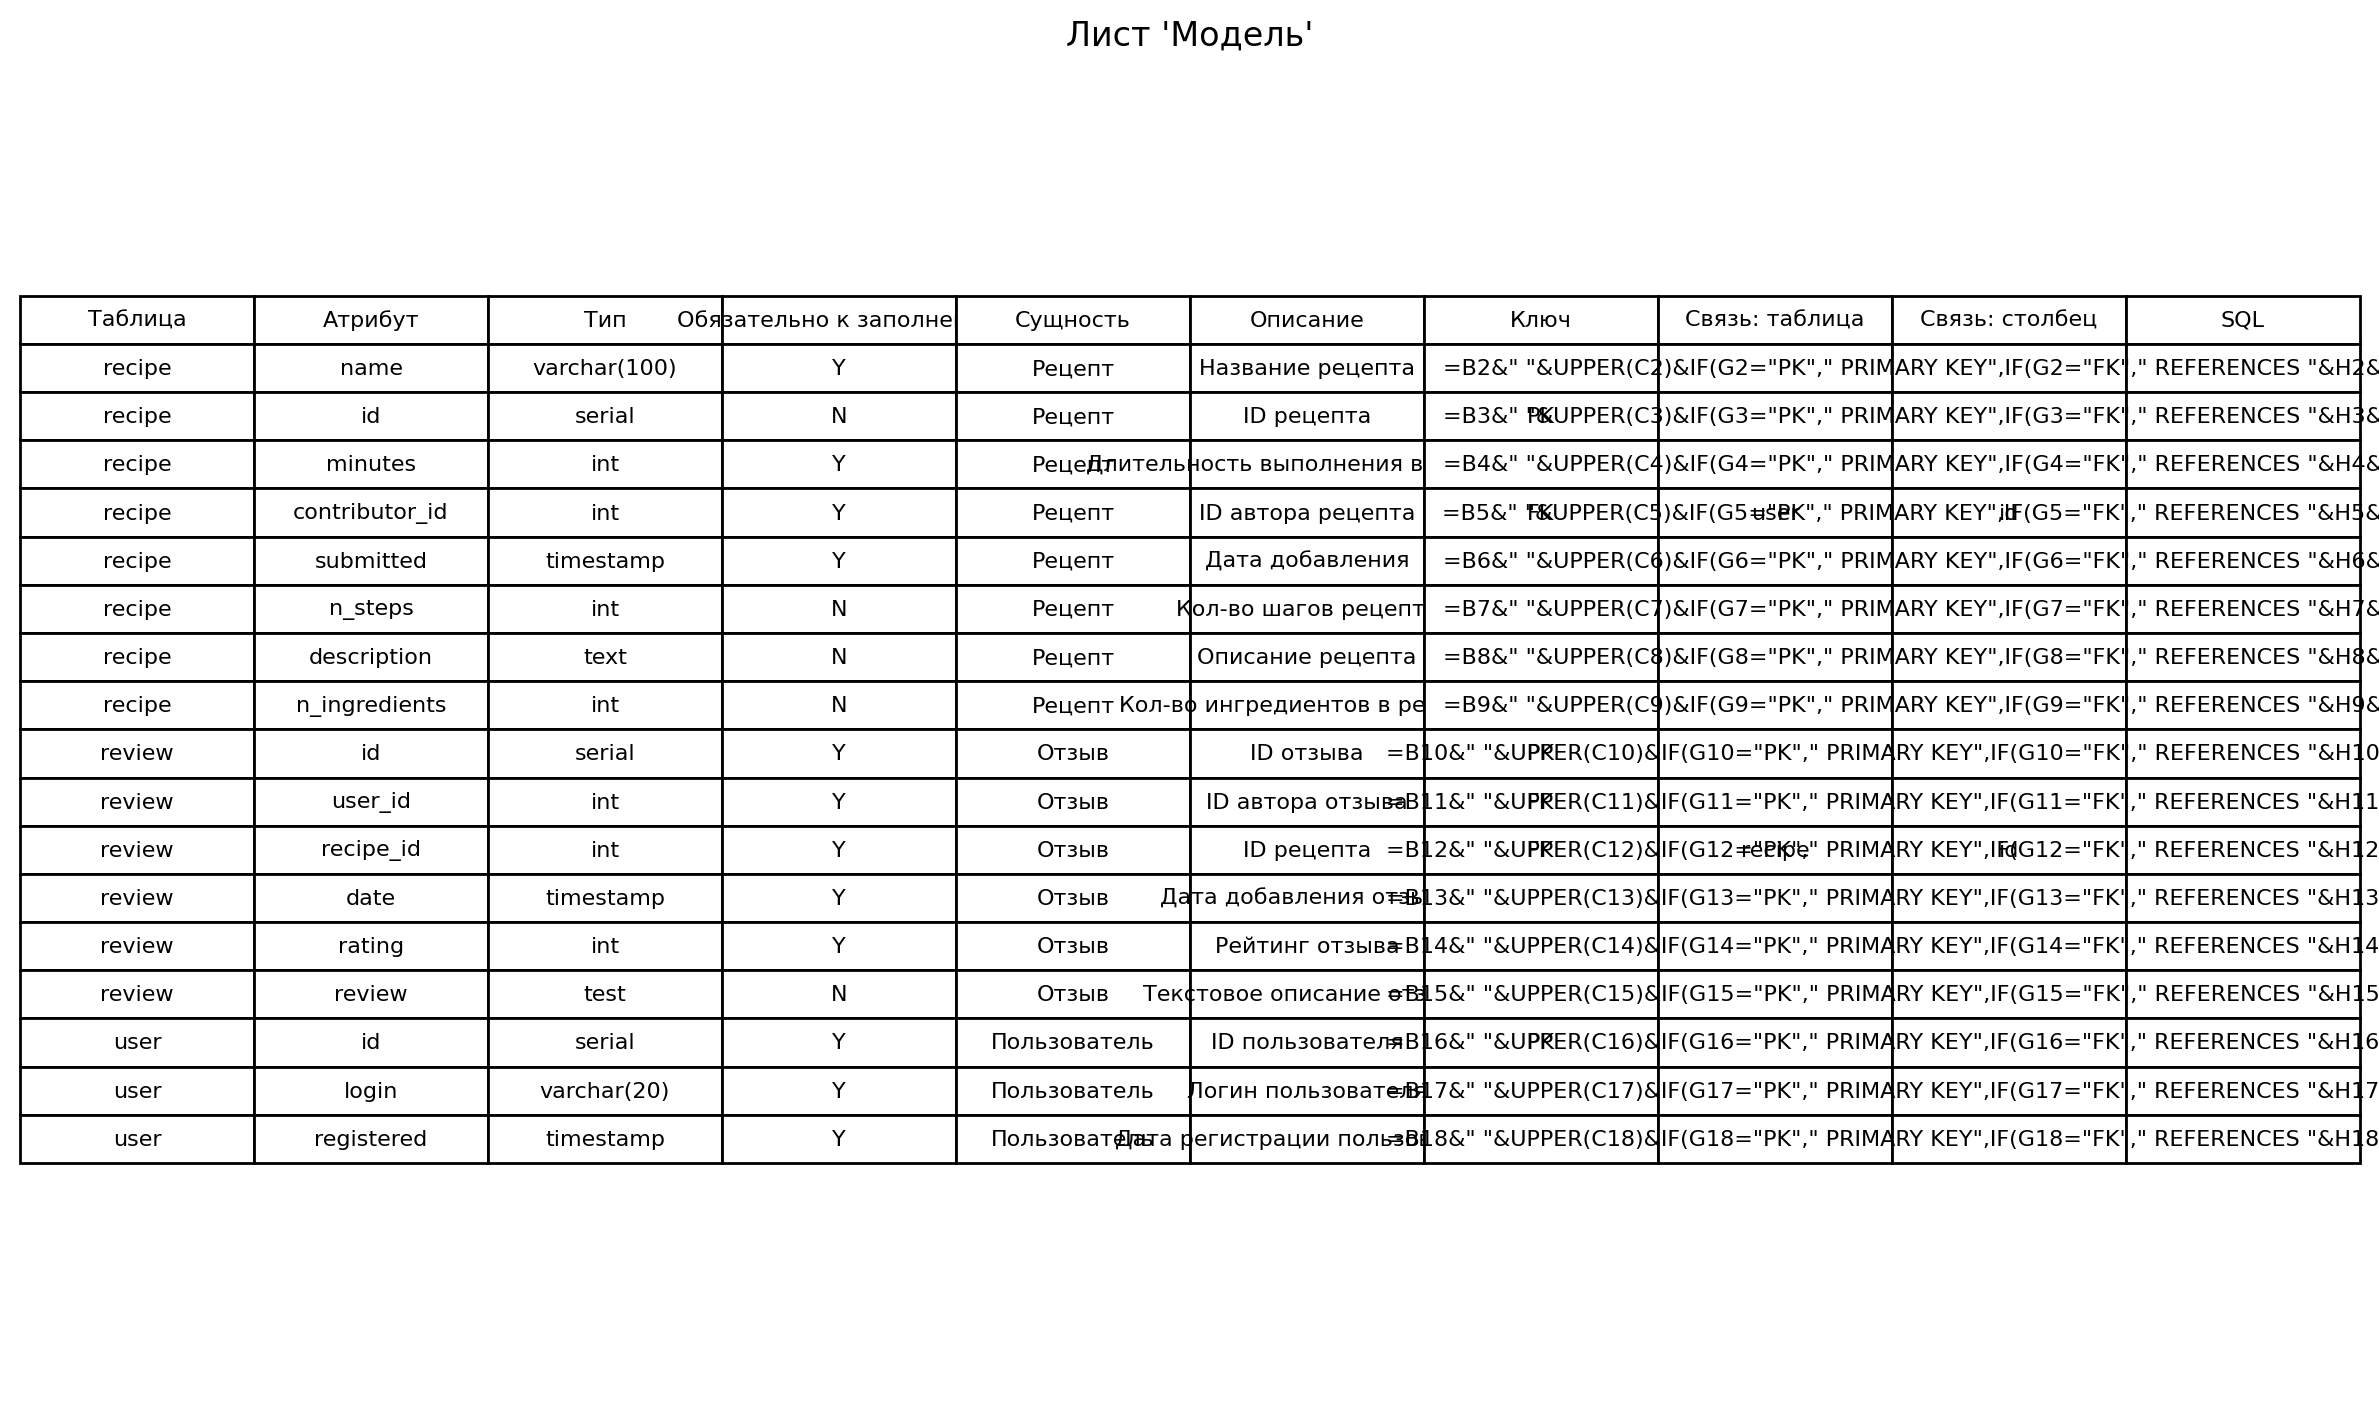

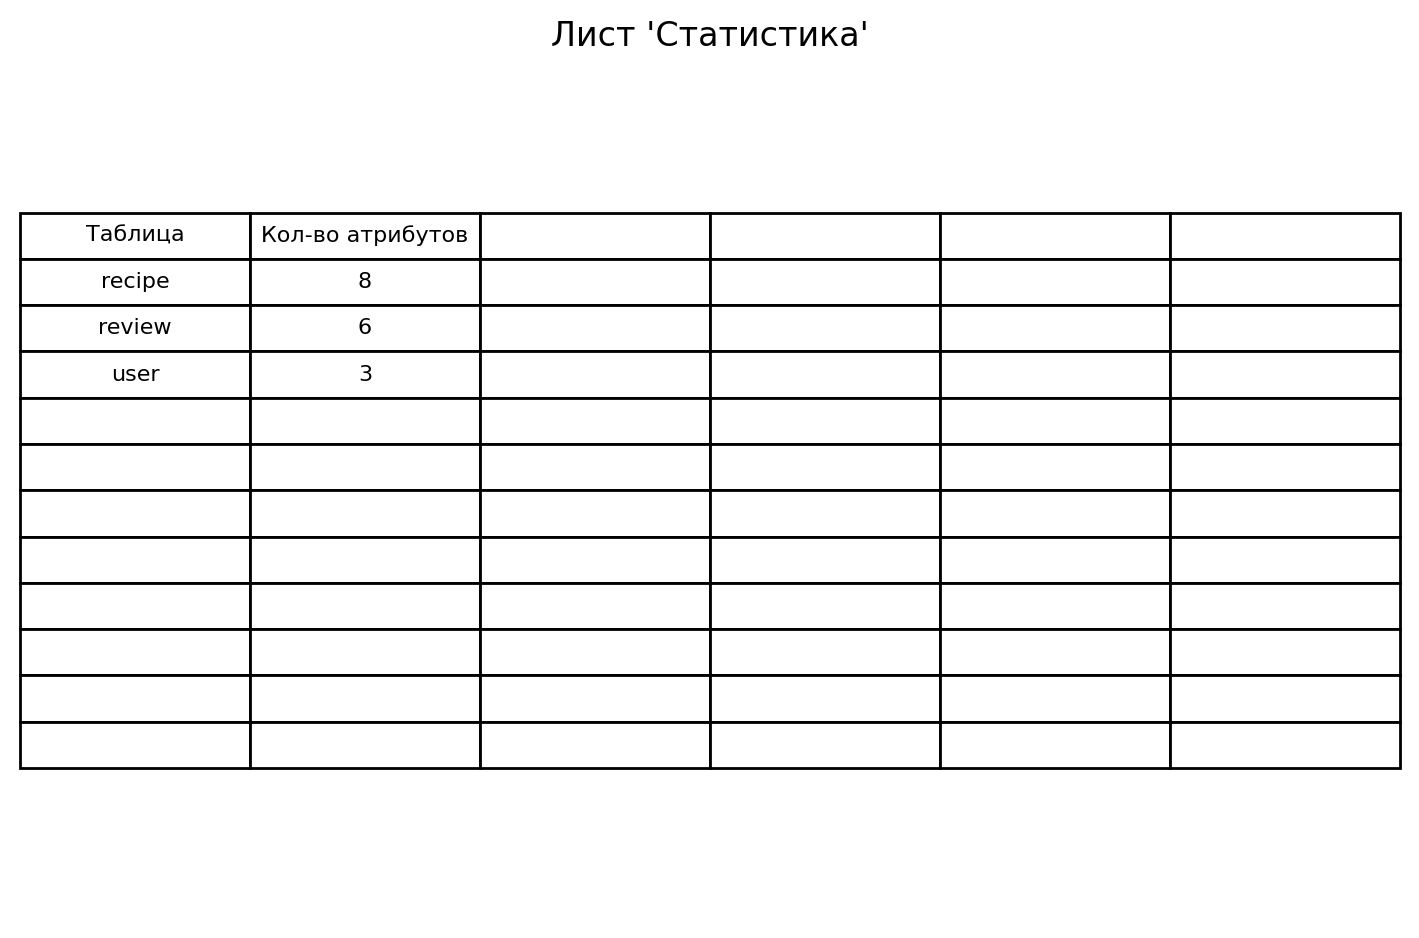

In [8]:

# Формируем "скриншоты" листов как изображения (рендер таблицы в matplotlib),
# затем выводим их в ноутбуке как подтверждение результата.

import matplotlib.pyplot as plt
import openpyxl
from openpyxl.utils.cell import range_boundaries
from IPython.display import Image, display

def sheet_to_image(ws, cell_range, outpath, title=None, dpi=200):
    min_col, min_row, max_col, max_row = range_boundaries(cell_range)
    data = []
    for r in range(min_row, max_row + 1):
        row = []
        for c in range(min_col, max_col + 1):
            v = ws.cell(r, c).value
            row.append("" if v is None else str(v))
        data.append(row)

    fig, ax = plt.subplots(figsize=(max(6, (max_col-min_col+1)*1.2), max(2.5,(max_row-min_row+1)*0.4)))
    ax.axis("off")
    tbl = ax.table(cellText=data, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.2)
    if title:
        ax.set_title(title)
    fig.tight_layout()
    fig.savefig(outpath, dpi=dpi, bbox_inches="tight")
    plt.close(fig)

wb = openpyxl.load_workbook("recipes_model.xlsx")
img_model = "model_sheet.png"
sheet_to_image(wb["Модель"], "A1:J18", img_model, title="Лист 'Модель'")

img_stat = "stats_sheet.png"
sheet_to_image(wb["Статистика"], "A1:F12", img_stat, title="Лист 'Статистика'")

display(Image(filename=img_model))
display(Image(filename=img_stat))
